In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

load_dotenv()

password = quote_plus(os.getenv("DB_PASSWORD"))
user = os.getenv("DB_USER", "root")
host = os.getenv("DB_HOST", "localhost")
db = os.getenv("DB_NAME", "olist_analytics")

engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{db}")

query = """
SELECT o.order_id, o.delivery_days, o.delivery_delay_days, o.order_purchase_timestamp,
       o.order_year_month, c.customer_state, r.review_score, oit.order_total_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
LEFT JOIN order_item_totals oit ON o.order_id = oit.order_id
WHERE o.is_delivered = 1
"""
df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(96715, 8)


,order_id,delivery_days,delivery_delay_days,order_purchase_timestamp,order_year_month,customer_state,review_score,order_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,7.0,-9.0,2017-09-13 08:59:02,2017-09,RJ,5.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,16.0,-3.0,2017-04-26 10:53:06,2017-04,SP,4.0,259.83
2,000229ec398224ef6ca0657da4fc703e,7.0,-14.0,2018-01-14 14:33:31,2018-01,MG,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,6.0,-6.0,2018-08-08 10:00:35,2018-08,SP,4.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,25.0,-16.0,2017-02-04 13:57:51,2017-02,SP,5.0,218.04


In [6]:
late = df[df["delivery_delay_days"] > 0]["review_score"].dropna()
on_time = df[df["delivery_delay_days"] <= 0]["review_score"].dropna()

t_stat, p_value = stats.ttest_ind(late, on_time, equal_var=False)
print(f"Late orders avg score: {late.mean():.2f} (n={len(late)})")
print(f"On-time orders avg score: {on_time.mean():.2f} (n={len(on_time)})")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

Late orders avg score: 2.27 (n=6360)
On-time orders avg score: 4.29 (n=89247)
T-statistic: -100.76, p-value: 0.00e+00


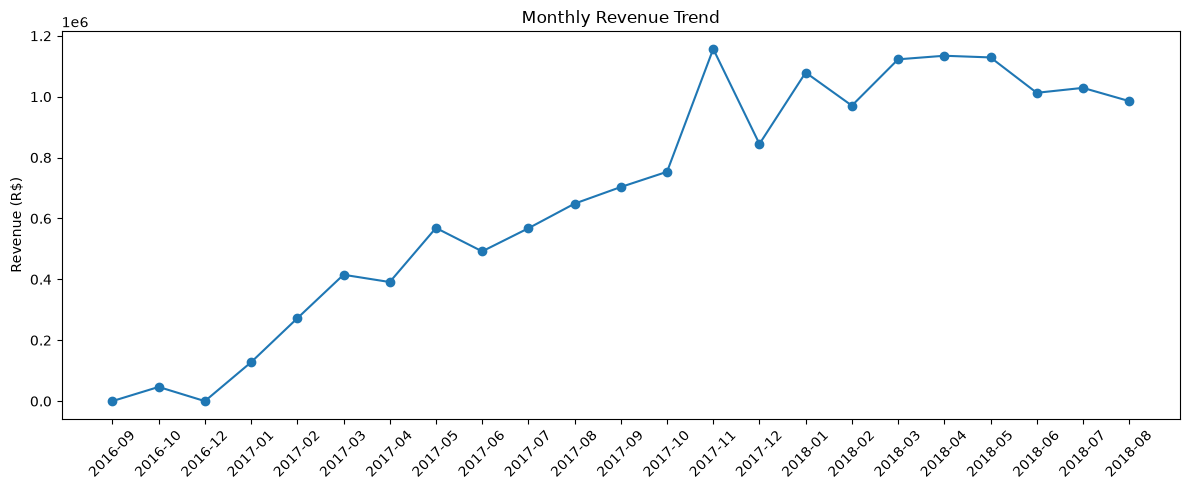

In [7]:
monthly = df.groupby("order_year_month")["order_total_value"].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(monthly["order_year_month"], monthly["order_total_value"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.savefig("../reports/monthly_revenue_trend.png")
plt.show()

<Figure size 800x500 with 0 Axes>

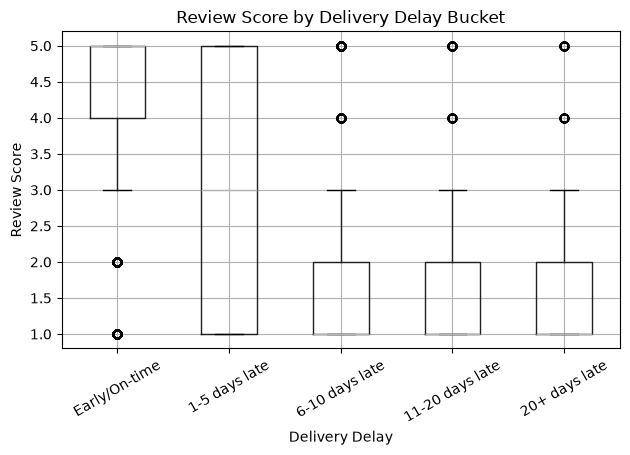

In [9]:
df["delay_bucket"] = pd.cut(
    df["delivery_delay_days"],
    bins=[-100, 0, 5, 10, 20, 100],
    labels=["Early/On-time", "1-5 days late", "6-10 days late", "11-20 days late", "20+ days late"]
)

plt.figure(figsize=(8,5))
df.boxplot(column="review_score", by="delay_bucket")
plt.title("Review Score by Delivery Delay Bucket")
plt.suptitle("")
plt.xlabel("Delivery Delay")
plt.ylabel("Review Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../reports/delay_vs_review.png")
plt.show()

In [10]:
corr = df[["order_total_value", "review_score", "delivery_delay_days"]].corr()
print(corr)

                     order_total_value  review_score  delivery_delay_days
order_total_value             1.000000     -0.041585            -0.017808
review_score                 -0.041585      1.000000            -0.267490
delivery_delay_days          -0.017808     -0.267490             1.000000
